# Section 4: Results

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from matplotlib.colors import ListedColormap

## Original Schelling Model

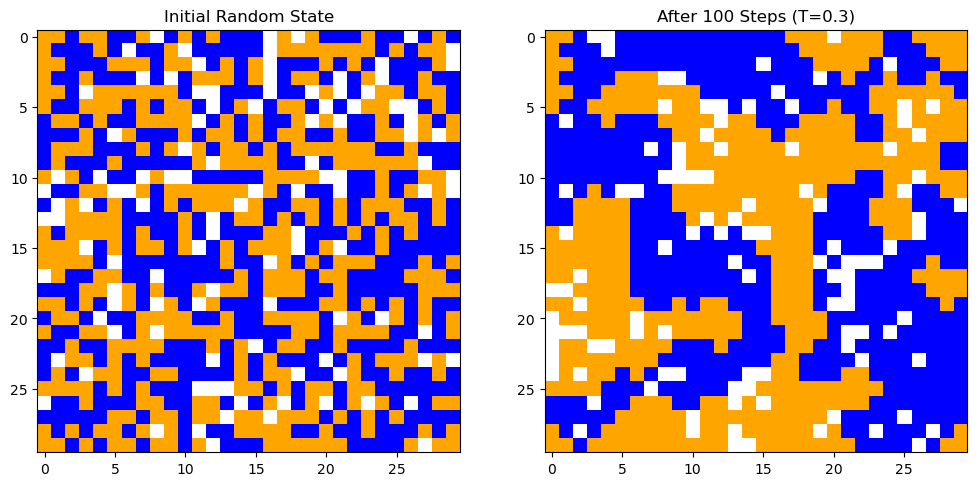

In [5]:
def original_schelling(cell_grid, threshold, max_iterations=100):
    """
    Simulates the Schelling model of segregation over multiple iterations."""
    
    for iteration in range(max_iterations):
        # Identify dissatisfied agents
        dissatisfied_agents = find_dissatisfied_agents(cell_grid, threshold)
        
        # Shuffle to randomize movement order
        np.random.shuffle(dissatisfied_agents)
        
        # Relocate dissatisfied agents
        cell_grid = relocate_agents(cell_grid, dissatisfied_agents)
    
    return cell_grid

def find_dissatisfied_agents(grid, threshold):
    """Identify agents who are dissatisfied with their current neighborhood."""
    unhappy = []
    rows, cols = grid.shape
    
    for i in range(rows):
        for j in range(cols):
            if grid[i, j] > 0:  # Cell is occupied
                # Get 3x3 neighborhood (with boundary checks)
                neighborhood = get_neighborhood(grid, i, j)
                
                # Calculate similarity ratio
                same_type = np.sum(neighborhood == grid[i, j]) - 1  # Exclude self
                total_neighbors = np.size(neighborhood) - 1
                
                if total_neighbors > 0 and (same_type / total_neighbors) < threshold:
                    unhappy.append((i, j))
    
    return unhappy

def get_neighborhood(grid, row, col):
    """Extract the 3x3 neighborhood around a cell with boundary handling."""
    row_start = max(0, row - 1)
    row_end = min(grid.shape[0], row + 2)
    col_start = max(0, col - 1)
    col_end = min(grid.shape[1], col + 2)
    
    return grid[row_start:row_end, col_start:col_end]

def relocate_agents(grid, moving_agents):
    """Move agents to random empty cells in the grid."""
    empty_cells= list(zip(*np.where(grid == 0)))
    np.random.shuffle(empty_cells)
    
    for old_row, old_col in moving_agents:
        if empty_cells:  # If there are empty cells available
            new_row, new_col = empty_cells.pop()
            grid[new_row, new_col] = grid[old_row, old_col]
            grid[old_row, old_col] = 0
    
    return grid

# Initialize and run
# 0: empty cells (10% probability
# 1: group A (45% probability)
# 2: group B (45% probability)
grid = np.random.choice([0, 1, 2], size=(30, 30), p=[0.1, 0.45, 0.45]) 
final_grid = original_schelling(grid.copy(), threshold=0.3) # Make a copy of initial grid and run for 100 steps with 30% threshold

# Define custom colors: 0=white, 1=blue, 2=orange
colors = ['white', 'blue', 'orange']
cmap = ListedColormap(colors)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6)) # Two side by side subplots
ax1.imshow(grid, cmap=cmap, vmin=0, vmax=2) # Initial State
ax1.set_title("Initial Random State")
ax2.imshow(final_grid, cmap=cmap, vmin=0, vmax=2) # Final State
ax2.set_title("After 100 Steps (T=0.3)")
plt.show()

## Extension Model with Markov Chain and Montecarlo Simulation

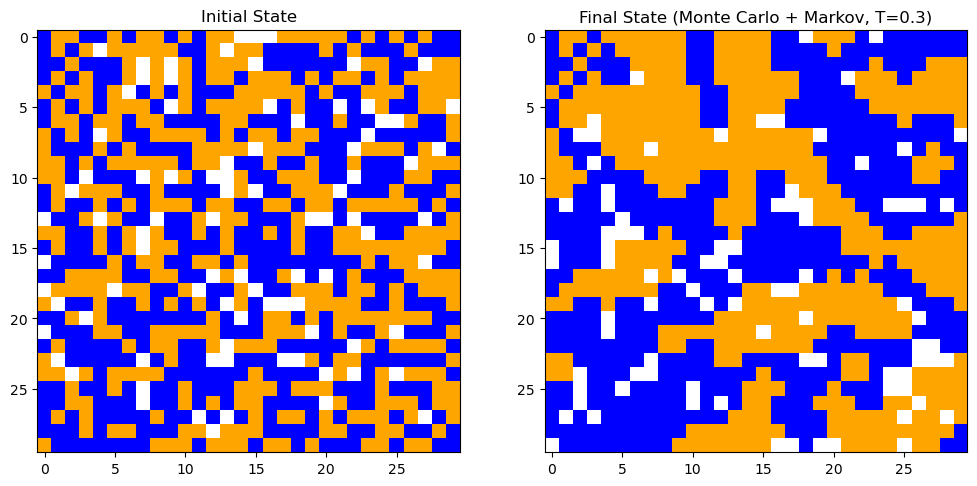

In [4]:
def schelling_monte_markov(initial_grid, threshold, n_steps=100):
    """
    Simulate the Schelling segregation model using a Monte Carlo approach
    with Markov-inspired random moves.
    """
    grid = initial_grid.copy()
    height, width = grid.shape
    
    for _ in range(n_steps):
        # Identify dissatisfied agents
        dissatisfied = []
        empty_cells = []
        
        for y in range(height):
            for x in range(width):
                if grid[y, x] == 0:
                    empty_cells.append((y, x))
                    continue
                
                # Count similar neighbors
                similar = 0
                total_neighbors = 0
                
                # Check all 8 surrounding cells
                for dy in [-1, 0, 1]:
                    for dx in [-1, 0, 1]:
                        if dy == 0 and dx == 0:
                            continue  # Skip self
                        
                        ny, nx = y + dy, x + dx
                        if 0 <= ny < height and 0 <= nx < width:
                            total_neighbors += 1
                            if grid[ny, nx] == grid[y, x]:
                                similar += 1
                
                # Check if dissatisfied
                if total_neighbors > 0 and similar / total_neighbors < threshold:
                    dissatisfied.append((y, x))
        
        # Randomize processing order
        np.random.shuffle(dissatisfied)
        np.random.shuffle(empty_cells)
        
        # Move dissatisfied agents
        for agent_pos in dissatisfied:
            if empty_cells:
                new_pos = empty_cells.pop()
                grid[new_pos] = grid[agent_pos]
                grid[agent_pos] = 0
    
    return grid
    
# Initialize grid
np.random.seed(0)
grid = np.random.choice([0, 1, 2], size=(30, 30), p=[0.1, 0.45, 0.45])
final_grid = schelling_monte_markov(grid.copy(), threshold=0.3)

# Custom color map
colors = ['white', 'blue', 'orange']
cmap = ListedColormap(colors)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(grid, cmap=cmap, vmin=0, vmax=2)
ax1.set_title("Initial State")
ax2.imshow(final_grid, cmap=cmap, vmin=0, vmax=2)
ax2.set_title("Final State (Monte Carlo + Markov, T=0.3)")
plt.show()

## Segregation Over Time Plot with Location Preferences (No Randomness)

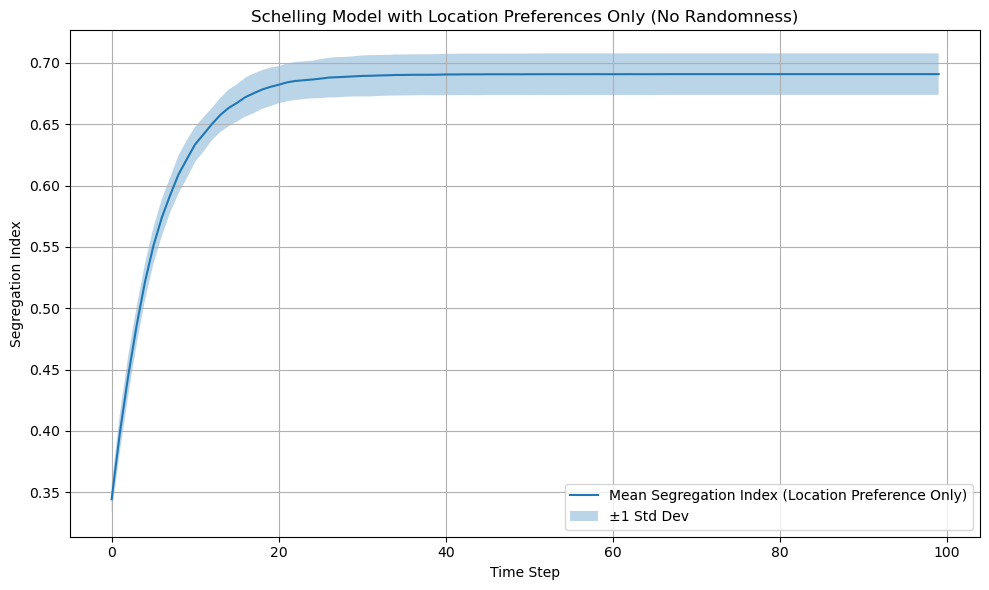

In [7]:
# Parameters
grid_size = 30              # Grid is 30x30
n_agents = 500              # Total agents
threshold = 0.3             # Happiness threshold
alpha = 0.3                 # Weight for location preference
p_random = 0.0              # Probability of random relocation: No randomness (stochastic relocation disabled)
n_steps = 100               # Steps per simulation
n_trials = 50               # Monte Carlo repetitions
desirable_loc = np.array([[15, 15]])  # Preferred center location

# --- DISTANCE MATRIX ---
# Matrix to store Manhattan distance of each cell from desirable location
rows, cols = np.indices((grid_size, grid_size))
coords = np.column_stack((rows.ravel(), cols.ravel())) # Flatten
distances = cdist(coords, desirable_loc, 'cityblock').reshape(grid_size, grid_size)

# --- FUNCTIONS ---
def initialize_grid():
    """Randomly assign agents to the grid with 10% empty cells."""
    grid = np.zeros((grid_size, grid_size), dtype=int)
    total_cells = grid_size * grid_size
    agent_locs = np.random.choice(total_cells, n_agents, replace=False) # Random agent location
    half = n_agents // 2
    grid.flat[agent_locs[:half]] = 1  # Type A
    grid.flat[agent_locs[half:]] = 2  # Type B
    return grid

def calculate_segregation(grid):
    """Compute segregation index as average fraction of similar neighbors per agent."""
    similarity = 0
    count = 0
    for i in range(grid_size):
        for j in range(grid_size):
            if grid[i, j] == 0:
                continue
            neighbors = grid[max(0, i-1):min(grid_size, i+2),
                             max(0, j-1):min(grid_size, j+2)]
            similar = np.sum(neighbors == grid[i, j]) - 1
            total = np.size(neighbors) - 1
            if total > 0:
                similarity += similar / total
                count += 1
    return similarity / count if count > 0 else 0

def simulate_schelling(grid, distances, threshold, alpha, p_random, n_steps):
    """Run Schelling simulation with location preferences."""
    # Track segregation at each step
    segregation_indices = []
    
    for step in range(n_steps):
        unhappy_agents = [] 

        # Evaluate happiness for each agent
        for i in range(grid_size):
            for j in range(grid_size):
                if grid[i, j] == 0: # Skip empty cells
                    continue

                # Calculate neighborhood happiness
                neighbors = grid[max(0, i-1):min(grid_size, i+2),
                                 max(0, j-1):min(grid_size, j+2)]
                similar = np.sum(neighbors == grid[i, j]) - 1
                total_neighbors = np.size(neighbors) - 1
                happiness_neighbors = similar / total_neighbors if total_neighbors > 0 else 0

                # Calculate location happiness 
                happiness_location = alpha / (1 + distances[i, j])
                # Combined happiness satisfaction
                happiness = happiness_neighbors + happiness_location

                # Check is agent is unhappy
                if happiness < threshold:  
                    unhappy_agents.append((i, j))
                    
        # Avoiding bias to randomize processing order 
        np.random.shuffle(unhappy_agents)

        # Find all empty cells
        empty_cells = np.where(grid.flat == 0)[0]

        # Relocate unhappy agents
        for i, j in unhappy_agents:
            if len(empty_cells) == 0: # Stop if no empty cells
                break
            
            # Select random empty cell and move agent there
            new_loc = np.random.choice(empty_cells)
            grid.flat[new_loc] = grid[i, j]
            grid[i, j] = 0 # Original location empty

            # Update empty cells list
            empty_cells = np.where(grid.flat == 0)[0]

        # Record segregation at this time step
        segregation_indices.append(calculate_segregation(grid))
    return grid, segregation_indices

# Monte Carlo Simulation
all_runs = []
for _ in range(n_trials):
    grid = initialize_grid()
    _, segregation = simulate_schelling(grid, distances, threshold, alpha, p_random, n_steps)
    all_runs.append(segregation) # Store segregation history

all_runs = np.array(all_runs)
mean_segregation = np.mean(all_runs, axis=0) # Average across trials
std_segregation = np.std(all_runs, axis=0) # Standard deviation across trials

# Plot segregation curve
plt.figure(figsize=(10, 6))
plt.plot(mean_segregation, label='Mean Segregation Index (Location Preference Only)')
plt.fill_between(range(n_steps),
                 mean_segregation - std_segregation,
                 mean_segregation + std_segregation,
                 alpha=0.3, label='±1 Std Dev')
plt.xlabel("Time Step")
plt.ylabel("Segregation Index")
plt.title("Schelling Model with Location Preferences Only (No Randomness)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Final Grid Visualisation (No Randomness)

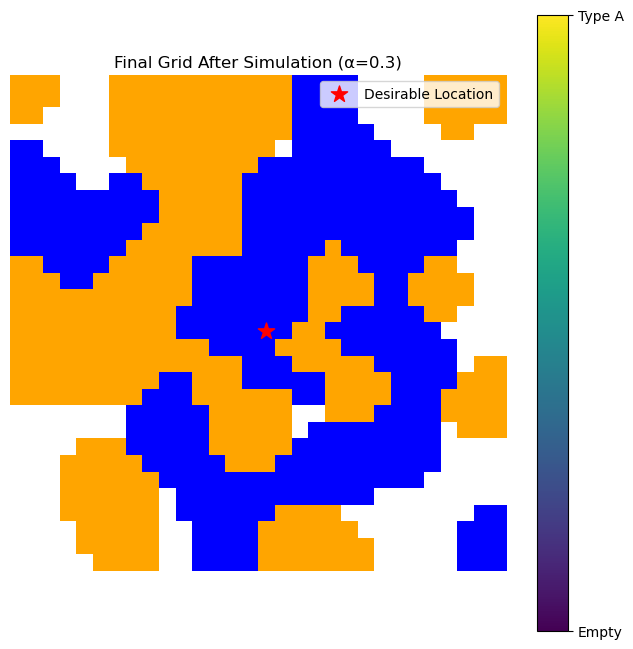

In [6]:
# Parameters
grid_size = 30
empty_ratio = 0.2
type_A = 0.4
threshold = 0.3  # proportion of similar neighbors required to stay
alpha = 0.3  # location preference weight
desirable_loc = (15, 15)  # center of grid

# Initialize grid
def initialize_grid():
    """Initialize the grid with random agent distribution."""
    cells = np.random.choice([0, 1, 2], size=(grid_size, grid_size),
                             p=[empty_ratio, type_A, 1 - empty_ratio - type_A])
    return cells

# Utility function
def compute_utility(grid, x, y, alpha):
    """
    Calculate utility score for agent at (x,y) combining neighborhood
    similarity and location preference.
    """
    agent = grid[x, y]
    if agent == 0: 
        return 0
    
    # Neighborhood similarity
    neighbors = []
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0: # Skip self
                continue
            nx, ny = x + dx, y + dy
            # Consider valid grid coordinates
            if 0 <= nx < grid_size and 0 <= ny < grid_size:
                neighbors.append(grid[nx, ny])
    
    # Fraction of similar neighbors
    if len(neighbors) == 0:
        similarity = 0 # Edge case: no neighbors
    else:
        same_type = sum(1 for n in neighbors if n == agent)
        similarity = same_type / len(neighbors)

    # Location preference
    dist = np.linalg.norm(np.array([x, y]) - np.array(desirable_loc))
    loc_pref = 1 / (1 + dist)  # closer = higher utility

    return (1 - alpha) * similarity + alpha * loc_pref

def is_happy(grid, x, y):
     """Determine if agent at (x,y) meets happiness threshold."""
    agent = grid[x, y]
    if agent == 0: # empty cells always happy
        return True
    utility = compute_utility(grid, x, y, ALPHA)
    return utility >= threshold

# Run simulation
def run_simulation(grid, max_iters=100):
    """Run Schelling simulation until equilibrium or max iterations."""
    for _ in range(max_iters):
        moved = False # Track if any agents moved this iteration
        unhappy_agents = [(x, y) for x in range(grid_size) for y in range(grid_size)
                          if grid[x, y] != 0 and not is_happy(grid, x, y)]
        empty_cells = [(x, y) for x in range(grid_size) for y in range(grid_size)
                       if grid[x, y] == 0]

        np.random.shuffle(unhappy_agents)

        # Attempt to relocate each unhappy agent
        for x, y in unhappy_agents:
            best_cell = None
            best_utility = compute_utility(grid, x, y, alpha) # Current utility

            # Evaluate all possible empty cells
            for i, j in empty_cells:
                # Create hypothetical grid with agent moved
                temp = grid.copy()
                temp[i, j] = grid[x, y]
                temp[x, y] = 0
                new_utility = compute_utility(temp, i, j, alpha)

                # Track best move
                if new_utility > best_utility:
                    best_cell = (i, j)
                    best_utility = new_utility
            
            # Execute best move if found
            if best_cell:
                i, j = best_cell
                grid[i, j], grid[x, y] = grid[x, y], 0 # Swap agent with empty
                moved = True
                empty_cells.remove((i, j))
                empty_cells.append((x, y))

        # If no agents moved, ealy termination
        if not moved:
            break
    return grid

def plot_grid(grid):
    cmap = ListedColormap(['white', 'blue', 'orange'])
    plt.figure(figsize=(8, 8))
    plt.imshow(grid, cmap=cmap, vmin=0, vmax=2)
    plt.scatter(desirable_loc[1], desirable_loc[0], color='red', marker='*', s=150, label='Desirable Location')
    plt.title(f"Final Grid After Simulation (α={ALPHA})")
    cbar = plt.colorbar(ticks=[0, 1, 2])
    cbar.ax.set_yticklabels(['Empty', 'Type A', 'Type B'])
    plt.legend(loc='upper right')
    plt.axis('off')
    plt.show()

# Run
grid = initialize_grid()
final_grid = run_simulation(grid)
plot_grid(final_grid)

## Segregation Over Time Plot (with Randomness)

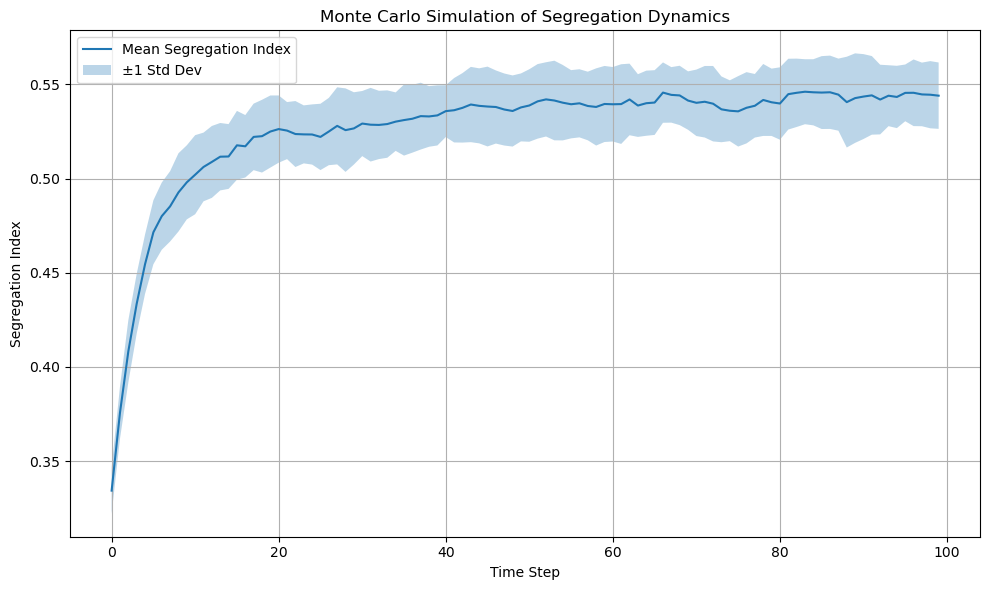

In [8]:
# Parameters
grid_size = 30              # Grid is 30x30
n_agents = 500              # Total agents
threshold = 0.3             # Happiness threshold
alpha = 0.3                 # Weight for location preference
p_random = 0.05             # Probability of random move
n_steps = 100               # Steps per simulation
n_trials = 50               # Monte Carlo repetitions
desirable_loc = np.array([[15, 15]])  # Preferred center location

# Distance Matrix: precompute Manhattan distance from each cell to desirable location
rows, cols = np.indices((grid_size, grid_size))
coords = np.column_stack((rows.ravel(), cols.ravel()))
distances = cdist(coords, desirable_loc, 'cityblock').reshape(grid_size, grid_size)

def initialize_grid():
    """Randomly assign agents to the grid with 10% empty cells."""
    grid = np.zeros((grid_size, grid_size), dtype=int)
    total_cells = grid_size * grid_size
    agent_locs = np.random.choice(total_cells, n_agents, replace=False) 
    half = n_agents // 2
    grid.flat[agent_locs[:half]] = 1  # Type A
    grid.flat[agent_locs[half:]] = 2  # Type B
    return grid

def calculate_segregation(grid):
    """Compute the average fraction of similar neighbors per agent."""
    similarity = 0
    count = 0 
    for i in range(grid_size):
        for j in range(grid_size):
            if grid[i, j] == 0: # Skip empty cells
                continue

            # Get 3x3 neighborhood (with edge handling)
            neighbors = grid[max(0, i-1):min(grid_size, i+2),
                             max(0, j-1):min(grid_size, j+2)]

            # Count similar neighbors (excluding self)
            similar = np.sum(neighbors == grid[i, j]) - 1
            total = np.size(neighbors) - 1
            
            # Evaluate only if agent has neighbors
            if total > 0:
                similarity += similar / total
                count += 1
    return similarity / count if count > 0 else 0


def simulate_schelling(grid, distances, threshold, alpha, p_random, n_steps):
    """Run the Schelling simulation"""
    segregation_indices = []
    
    for step in range(n_steps):
        unhappy_agents = []
        
        # Evaluate happiness for each agent
        for i in range(grid_size):
            for j in range(grid_size):
                if grid[i, j] == 0: # Skip empty cells
                    continue

                # Calculate neighborhood happiness
                neighbors = grid[max(0, i-1):min(grid_size, i+2),
                             max(0, j-1):min(grid_size, j+2)]
                similar = np.sum(neighbors == grid[i, j]) - 1
                total_neighbors = np.size(neighbors) - 1
                happiness_neighbors = similar / total_neighbors if total_neighbors > 0 else 0
                
                # Calculate location happiness (inverse distance)
                happiness_location = alpha / (1 + distances[i, j])

                # Combined happiness score
                happiness = happiness_neighbors + happiness_location

                # Agents unhappy
                if happiness < threshold or np.random.rand() < p_random:
                    unhappy_agents.append((i, j))

        np.random.shuffle(unhappy_agents)
        empty_cells = np.where(grid.flat == 0)[0]

        # Relocate unhappy agents
        for i, j in unhappy_agents:
            if len(empty_cells) == 0: # No empty cell, stop
                break
                
            # Select random empty cell and move agent
            new_loc = np.random.choice(empty_cells)
            grid.flat[new_loc] = grid[i, j]
            grid[i, j] = 0 
            empty_cells = np.where(grid.flat == 0)[0]\

        # Record segregation at this time step
        segregation_indices.append(calculate_segregation(grid))
    return grid, segregation_indices


# Monte Carlo simulation
all_runs = []

for _ in range(n_trials):
    grid = initialize_grid()
    _, segregation = simulate_schelling(grid, distances, threshold, alpha, p_random, n_steps)
    all_runs.append(segregation)

all_runs = np.array(all_runs)
mean_segregation = np.mean(all_runs, axis=0)
std_segregation = np.std(all_runs, axis=0)

# Plot segregation
plt.figure(figsize=(10, 6))
plt.plot(mean_segregation, label='Mean Segregation Index')
plt.fill_between(range(n_steps),
                 mean_segregation - std_segregation,
                 mean_segregation + std_segregation,
                 alpha=0.3, label='±1 Std Dev')
plt.xlabel("Time Step")
plt.ylabel("Segregation Index")
plt.title("Monte Carlo Simulation of Segregation Dynamics")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Final Grid Visualisation (with randomness)

C:\Users\USER\AppData\Local\Temp\ipykernel_31632\2272805717.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(final_grid, cmap=plt.cm.get_cmap('viridis', 3), vmin=0, vmax=2)


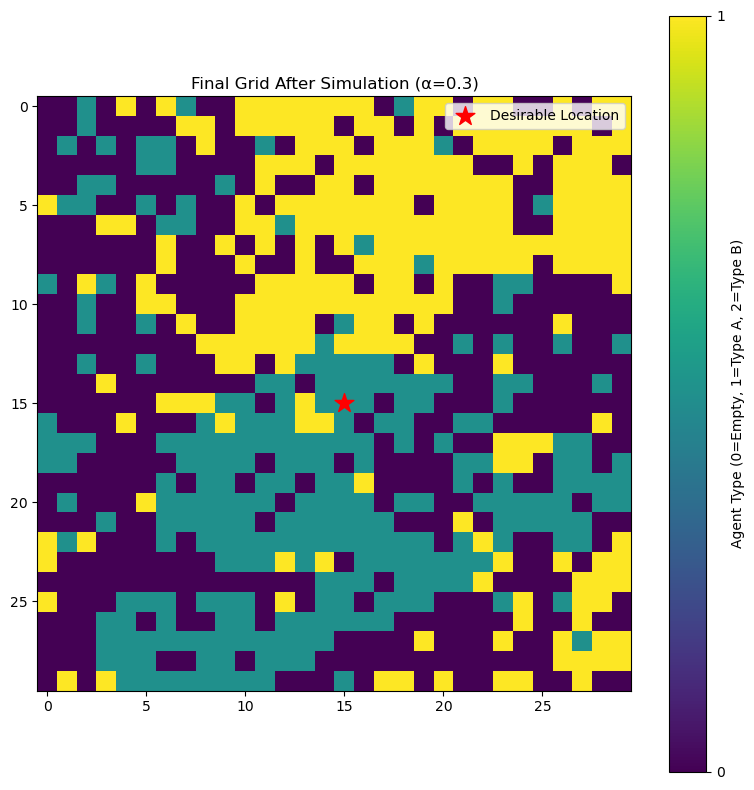

In [9]:
final_grid, _ = simulate_schelling(initialize_grid(), distances, threshold, alpha, p_random, n_steps)

plt.figure(figsize=(8, 8))
plt.imshow(final_grid, cmap=plt.cm.get_cmap('viridis', 3), vmin=0, vmax=2)
plt.scatter(desirable_loc[:, 1], desirable_loc[:, 0], c='red', s=200, marker='*', label='Desirable Location')
plt.colorbar(ticks=[0, 1, 2], label='Agent Type (0=Empty, 1=Type A, 2=Type B)')
plt.title(f"Final Grid After Simulation (α={alpha})")
plt.legend()
plt.tight_layout()
plt.show()

## Randomness and Segregation Disruption

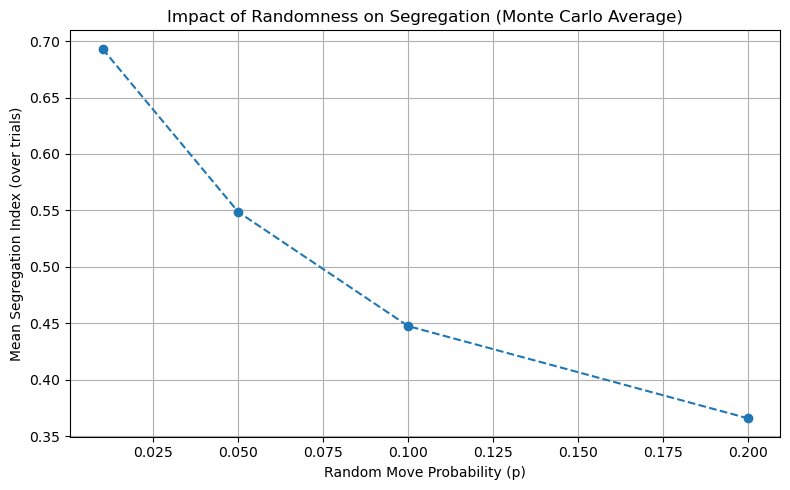

In [10]:
p_values = [0.01, 0.05, 0.10, 0.20]
n_trials = 20
mean_segregations = [] # Average final segregation for each p-value

for p in p_values:
    trial_results = []
    for _ in range(n_trials):
        grid = initialize_grid()
        _, indices = simulate_schelling(grid.copy(), distances, threshold, alpha, p, n_steps=500)
        trial_results.append(indices[-1])  # final segregation index
    mean_segregations.append(np.mean(trial_results))

# Plot visualisation
plt.figure(figsize=(8, 5))
plt.plot(p_values, mean_segregations, marker='o', linestyle='--')
plt.xlabel("Random Move Probability (p)")
plt.ylabel("Mean Segregation Index (over trials)")
plt.title("Impact of Randomness on Segregation (Monte Carlo Average)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Happiness Distribution with/without Location Preferences

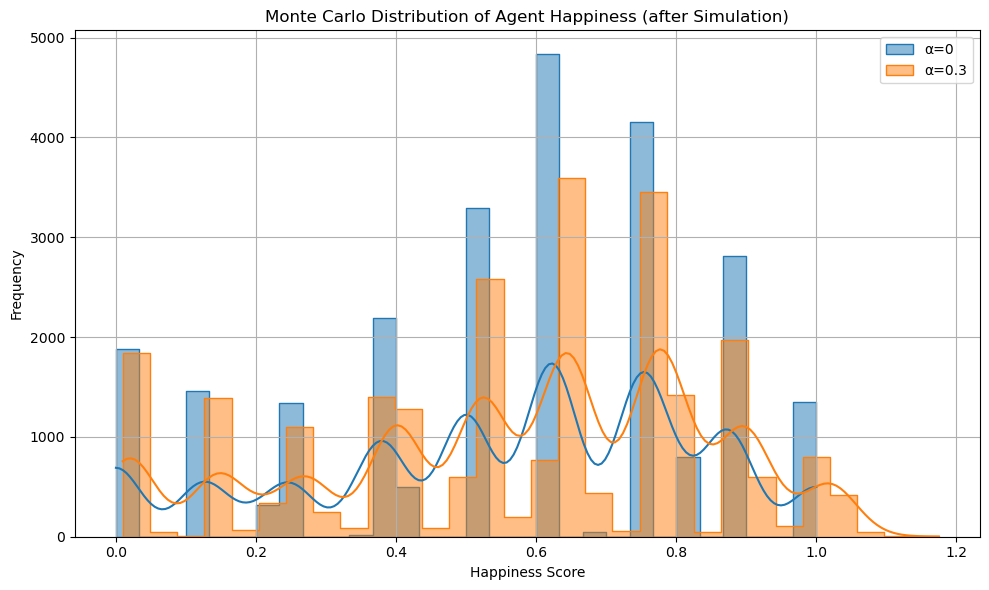

In [11]:
n_trials = 50
alpha_values = [0, 0.3]
final_happiness = {alpha: [] for alpha in alpha_values}

def calculate_happiness(grid, distances, alpha):
    """Calculate agent happiness based on neighbors and location preference."""
    happiness = []
    for i in range(grid_size):
        for j in range(grid_size):
            if grid[i, j] == 0: # Skip empty cells
                continue

            # Get 3x3 neighborhood (with edge handling)
            neighbors = grid[max(0, i-1):min(grid_size, i+2),
                            max(0, j-1):min(grid_size, j+2)]
            similar = np.sum(neighbors == grid[i, j]) - 1
            total = np.size(neighbors) - 1 # Total neighbors
            h_neighbors = similar / total if total > 0 else 0 
            h_location = alpha / (1 + distances[i, j]) # Calculate location happiness
            happiness.append(h_neighbors + h_location) # Combined happiness score
    return happiness

# Run Monte Carlo simulations
for alpha in alpha_values:
    for _ in range(n_trials):
        grid = initialize_grid()
        final_grid, _ = simulate_schelling(grid, distances, threshold, alpha, p_random, n_steps)
        happiness = calculate_happiness(final_grid, distances, alpha)
        final_happiness[alpha].extend(happiness)

# Plot histograms
plt.figure(figsize=(10, 6))
for alpha, happiness_list in final_happiness.items():
    label = f"α={alpha}"
    sns.histplot(happiness_list, kde=True, label=label, bins=30, element='step')

plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.title("Monte Carlo Distribution of Agent Happiness (after Simulation)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()